# Notebook 07 - Aplicaciones Empresariales

## Objetivos
- Analizar casos reales por sector desde CSV.
- Visualizar distribucion de aplicaciones y arquitecturas.
- Discutir 20+ ejemplos de empresas con Transformers.

## Introduccion
Las arquitecturas Transformer ya impactan finanzas, salud, retail y tecnologia. Mapearemos casos del dataset a tipos de modelo y valor de negocio.

In [1]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RUTA = Path('..') / 'datasets' / 'casos_empresariales.csv'
df = pd.read_csv(RUTA)
print('Empresas cargadas:', len(df))

Empresas cargadas: 20


## 1) Exploracion del dataset

In [2]:
display(df.head(10))
print('Columnas:', df.columns.tolist())

,empresa,sector,aplicacion,modelo_tipo,descripcion
0,Netflix,Entretenimiento,Recomendación de contenido,Encoder + embeddings,Personaliza sugerencias de series y películas ...
1,Amazon,E-commerce,Búsqueda y recomendación,Encoder + ranking,Mejora resultados de búsqueda y sugerencias de...
2,Spotify,Música,Recomendación y playlists,Embeddings + clasificación,Sugiere canciones y crea playlists según prefe...
3,Google,Tecnología,Búsqueda y traducción,Encoder-Decoder + LLM,Traduce idiomas y responde consultas con model...
4,Microsoft,Tecnología,Copilot y productividad,Decoder-only LLM,Asiste en código y documentos integrando GPT e...
5,OpenAI,Tecnología,ChatGPT y APIs,Decoder-only LLM,Genera texto conversacional y resuelve tareas ...
6,Tesla,Automotriz,Procesamiento de voz y comandos,Encoder + ASR,Interpreta comandos de voz y texto en interfac...
7,BBVA,Finanzas,Análisis de documentos,Encoder-only,Clasifica contratos y extrae cláusulas relevan...
8,Hospital Clínic,Salud,Resumen de historiales,Encoder-Decoder,Resume notas clínicas para apoyar decisiones m...
9,Universidad Stanford,Educación,Tutoría y corrección,Decoder-only LLM,Apoya aprendizaje con explicaciones y retroali...


Columnas: ['empresa', 'sector', 'aplicacion', 'modelo_tipo', 'descripcion']


## 2) Analisis por sector

In [3]:
por_sector = df.groupby('sector').size().reset_index(name='conteo')
display(por_sector.sort_values('conteo', ascending=False))

,sector,conteo
13,Tecnología,4
1,E-commerce,2
2,Educación,2
4,Finanzas,2
0,Automotriz,1
3,Entretenimiento,1
5,Legal,1
6,Logística,1
7,Marketing,1
8,Música,1


## 3) Visualizaciones

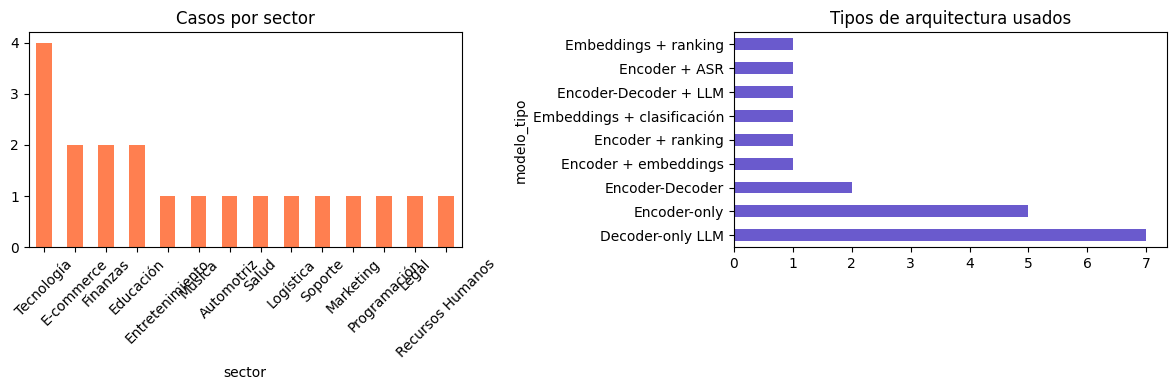

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sector'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Casos por sector')
axes[0].tick_params(axis='x', rotation=45)

df['modelo_tipo'].value_counts().plot(kind='barh', ax=axes[1], color='slateblue')
axes[1].set_title('Tipos de arquitectura usados')

plt.tight_layout()
plt.show()

## 4) Mapeo arquitectura -> caso de uso

In [5]:
mapa = df.groupby(['modelo_tipo', 'aplicacion']).size().reset_index(name='frecuencia')
display(mapa.sort_values('frecuencia', ascending=False))

,modelo_tipo,aplicacion,frecuencia
0,Decoder-only LLM,Autocompletado de código,1
1,Decoder-only LLM,ChatGPT y APIs,1
18,Encoder-only,Clasificación de correos,1
17,Encoder-only,Búsqueda jurídica,1
16,Encoder-only,Análisis de riesgo textual,1
15,Encoder-only,Análisis de documentos,1
14,Encoder-Decoder + LLM,Búsqueda y traducción,1
13,Encoder-Decoder,Resumen de lecciones,1
12,Encoder-Decoder,Resumen de historiales,1
11,Encoder + ranking,Búsqueda y recomendación,1


## 5) Discusion: 20 empresas reales

In [6]:
# Mostramos todas las empresas con su valor de negocio
for i, row in df.iterrows():
    print(f"{i+1:02d}. {row['empresa']} ({row['sector']})")
    print(f"    Aplicacion: {row['aplicacion']}")
    print(f"    Modelo: {row['modelo_tipo']}")
    print(f"    Valor: {row['descripcion']}")
    print('-' * 70)

01. Netflix (Entretenimiento)
    Aplicacion: Recomendación de contenido
    Modelo: Encoder + embeddings
    Valor: Personaliza sugerencias de series y películas según historial y similitud semántica.
----------------------------------------------------------------------
02. Amazon (E-commerce)
    Aplicacion: Búsqueda y recomendación
    Modelo: Encoder + ranking
    Valor: Mejora resultados de búsqueda y sugerencias de productos con modelos de lenguaje.
----------------------------------------------------------------------
03. Spotify (Música)
    Aplicacion: Recomendación y playlists
    Modelo: Embeddings + clasificación
    Valor: Sugiere canciones y crea playlists según preferencias y contexto.
----------------------------------------------------------------------
04. Google (Tecnología)
    Aplicacion: Búsqueda y traducción
    Modelo: Encoder-Decoder + LLM
    Valor: Traduce idiomas y responde consultas con modelos Transformer a gran escala.
-----------------------------------

## 6) Heatmap sector vs tipo de modelo

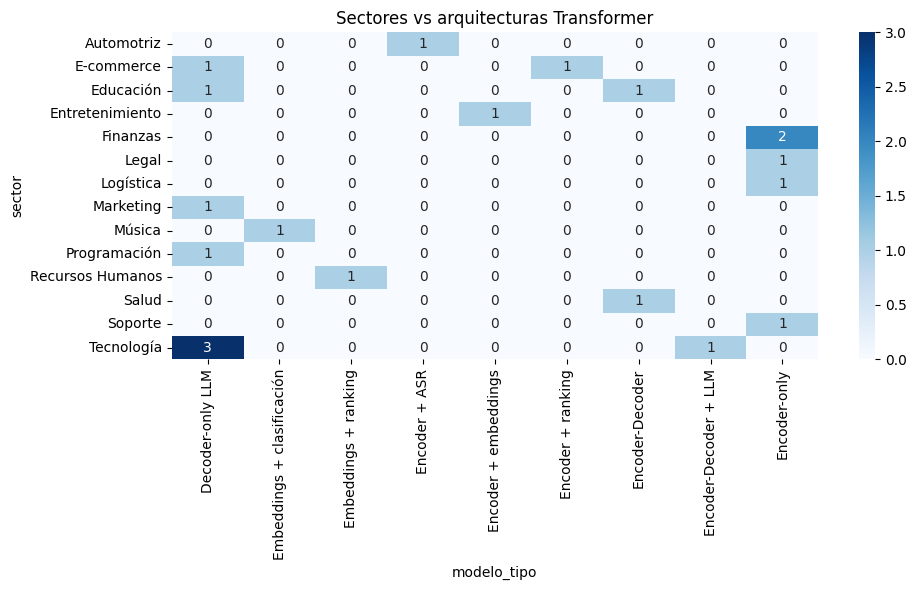

In [7]:
pivot = pd.crosstab(df['sector'], df['modelo_tipo'])
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Sectores vs arquitecturas Transformer')
plt.tight_layout()
plt.show()

## Resultados
Analizamos 20 casos empresariales, visualizamos sectores y arquitecturas, y relacionamos aplicaciones con tipos de modelo.

## Conclusiones
El valor empresarial no viene solo del tamano del modelo, sino de integrarlo en flujos con metricas, seguridad y supervision humana cuando aplica.

## Ejercicios guiados resueltos
**Ejercicio:** Encuentra el sector con mayor diversidad de arquitecturas.

**Solucion:**

In [8]:
diversidad = pivot.astype(bool).sum(axis=1).sort_values(ascending=False)
print('Sector mas diverso:', diversidad.index[0], 'con', diversidad.iloc[0], 'tipos')

Sector mas diverso: E-commerce con 2 tipos


## Ejercicios propuestos
1. Agrega 5 casos colombianos/latam con fuentes publicas.
2. Estima costo computacional por tipo de arquitectura.
3. Define KPIs para un chatbot de soporte en e-commerce.

## Preguntas de reflexion
1. Que sectores priorizan encoder-only y por que?
2. Como mitigar alucinaciones en finanzas o salud?
3. Que datos internos NO deberian enviarse a APIs publicas?